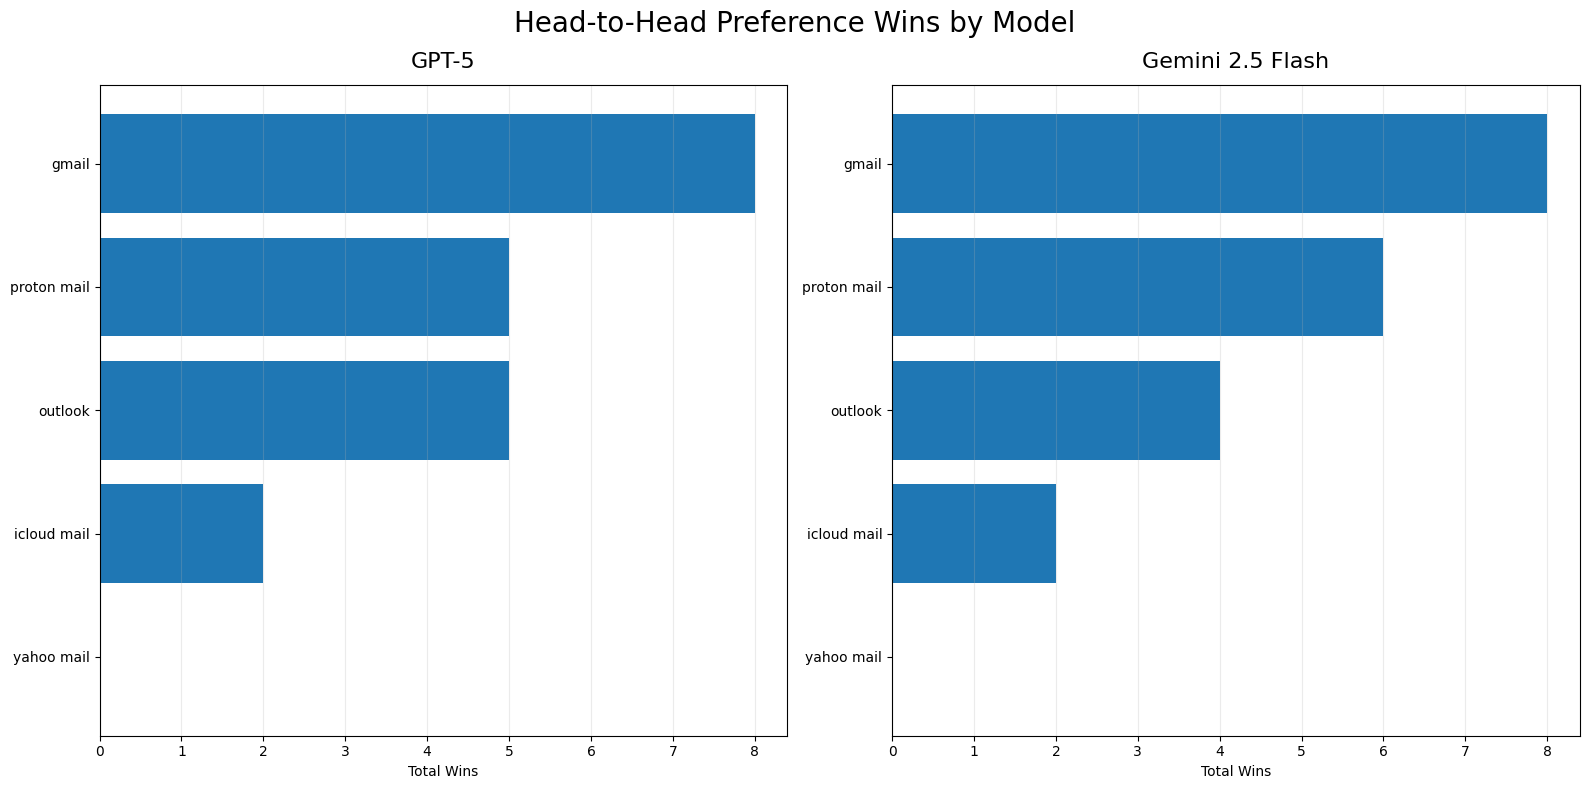

In [15]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gemini.parquet"


def load_wins(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "num_wins")
        .with_columns(pl.col("value").cast(pl.Int64).alias("wins"))
        .group_by("entity_name")
        .agg(pl.col("wins").sum())
        .sort("wins")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_wins(gpt_path)
gemini = load_wins(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["wins"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Total Wins")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(gemini["entity"], gemini["wins"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Total Wins")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Head-to-Head Preference Wins by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

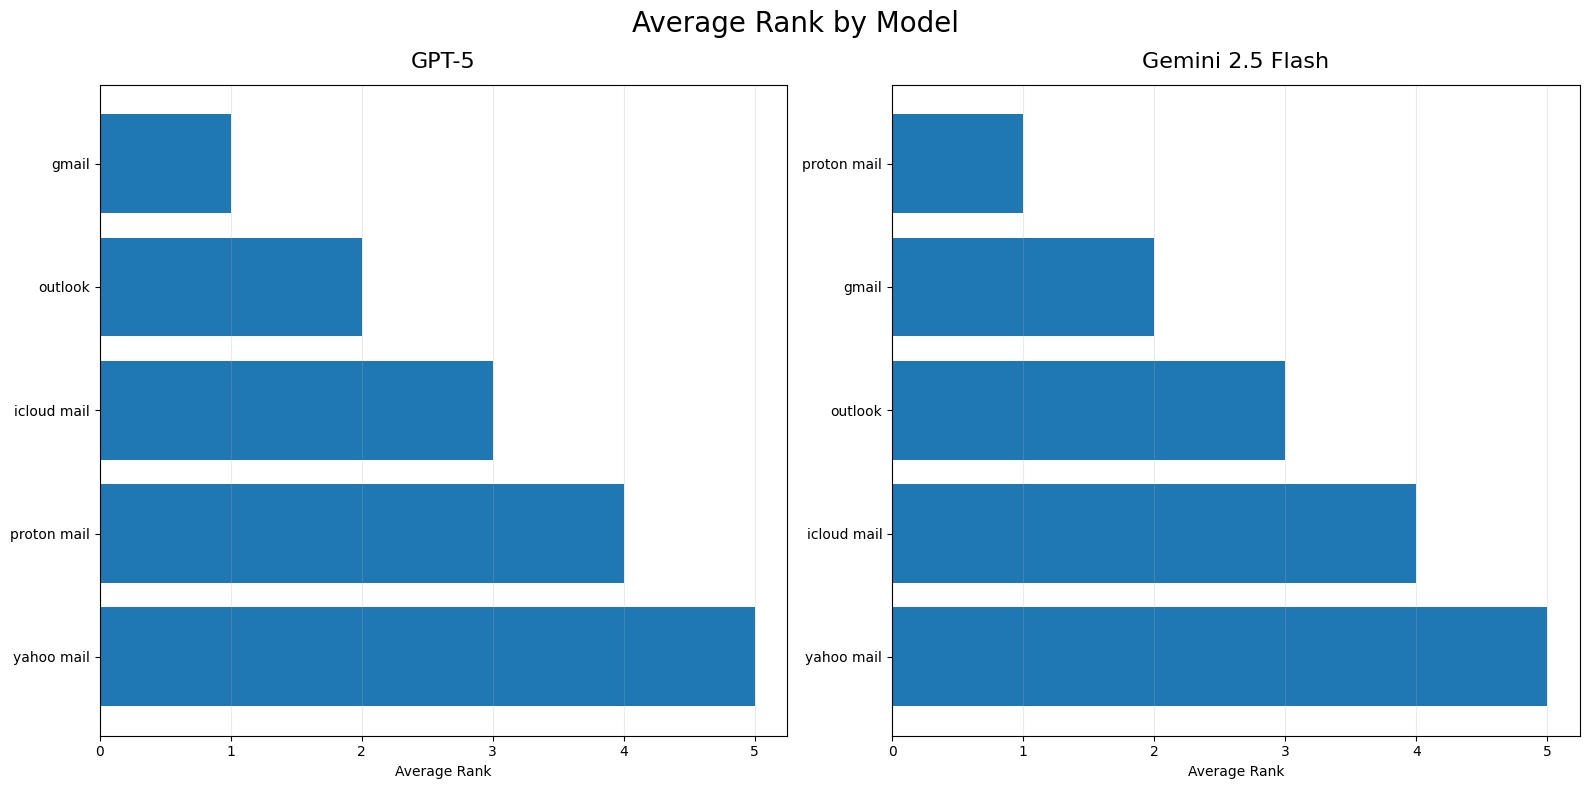

In [16]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/rank/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/rank/gemini.parquet"


def load_average_rank(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "rank")
        .with_columns(pl.col("value").cast(pl.Int64).alias("rank"))
        .group_by("entity_name")
        .agg(pl.col("rank").mean().alias("average_rank"))
        .sort("average_rank", descending=True)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_average_rank(gpt_path)
gemini = load_average_rank(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["average_rank"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Average Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].invert_xaxis()

axes[1].barh(gemini["entity"], gemini["average_rank"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Average Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].invert_xaxis()

fig.suptitle("Average Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

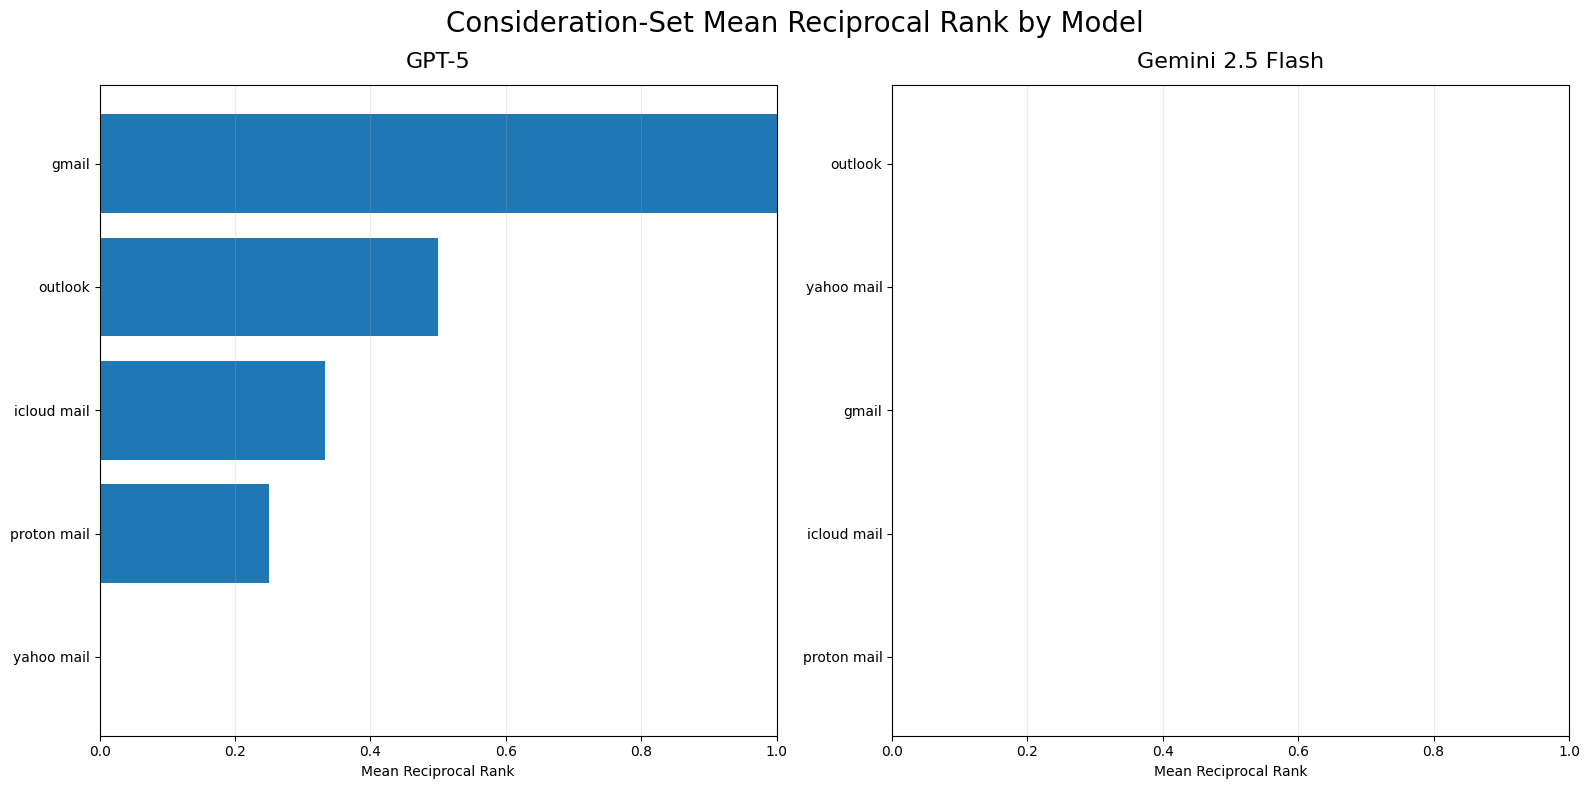

In [17]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/consideration-set/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/consideration-set/gemini.parquet"


def load_mrr(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "mean_reciprocal_rank")
        .with_columns(pl.col("value").cast(pl.Float64).alias("reciprocal_rank"))
        .group_by("entity_name")
        .agg(pl.col("reciprocal_rank").mean().alias("mrr"))
        .sort("mrr")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_mrr(gpt_path)
gemini = load_mrr(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["mrr"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Mean Reciprocal Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(0, 1)

axes[1].barh(gemini["entity"], gemini["mrr"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Mean Reciprocal Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(0, 1)

fig.suptitle("Consideration-Set Mean Reciprocal Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

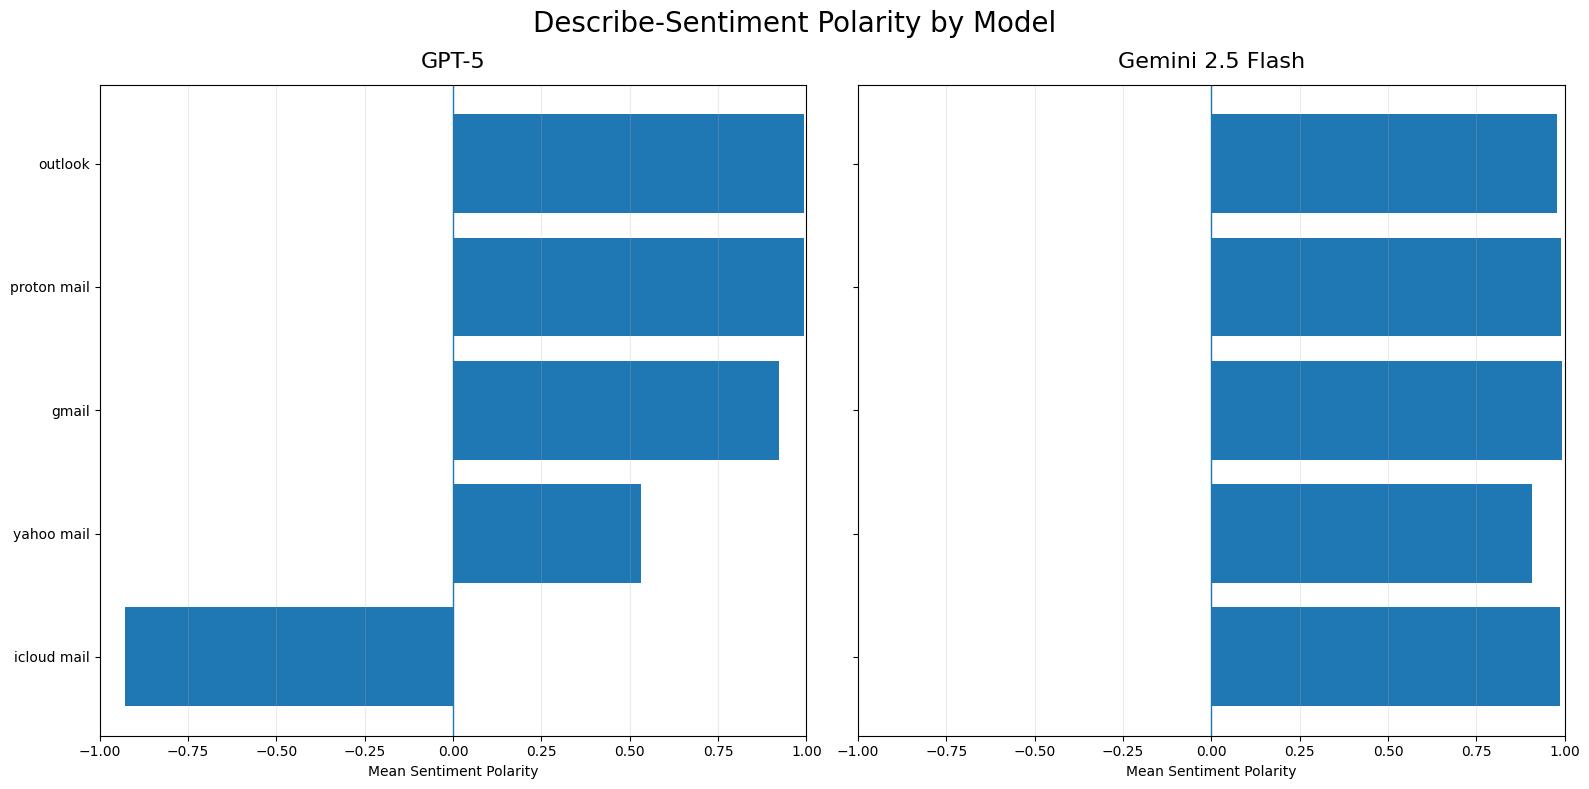

In [20]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"


def load_metric(path: str, estimand: str, metric_name: str):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == estimand)
        .with_columns(pl.col("value").cast(pl.Float64).alias(metric_name))
        .group_by("entity_name")
        .agg(pl.col(metric_name).mean().alias(metric_name))
        .sort(metric_name)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


# Choose one:
ESTIMAND = "sentiment_polarity"
#ESTIMAND = "ad_likelihood"

if ESTIMAND == "sentiment_polarity":
    metric_name = "mean_sentiment"
    xlabel = "Mean Sentiment Polarity"
    xlim = (-1, 1)
    title = "Describe-Sentiment Polarity by Model"
elif ESTIMAND == "ad_likelihood":
    metric_name = "mean_ad_likelihood"
    xlabel = "Mean Ad Likelihood"
    xlim = (0, 1)
    title = "Describe-Sentiment Ad Likelihood by Model"
else:
    raise ValueError(f"Unsupported estimand: {ESTIMAND}")

gpt = load_metric(gpt_path, ESTIMAND, metric_name)
gemini = load_metric(gemini_path, ESTIMAND, metric_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt[metric_name])
axes[0].axvline(0, linewidth=1)
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(*xlim)

axes[1].barh(gemini["entity"], gemini[metric_name])
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(*xlim)

fig.suptitle(title, fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

In [19]:
import polars as pl

path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"

df = pl.read_parquet(path)

scores = (
    df.explode("result")
    .with_columns(
        pl.col("result").struct.field("estimand").alias("estimand"),
        pl.col("result").struct.field("value").alias("value"),
    )
    .filter(pl.col("estimand") == "ad_likelihood")
    .with_columns(pl.col("value").cast(pl.Float64).alias("ad_likelihood"))
    .select(["entity_name", "ad_likelihood"])
)

print(scores)

shape: (5, 2)
┌─────────────┬───────────────┐
│ entity_name ┆ ad_likelihood │
│ ---         ┆ ---           │
│ str         ┆ f64           │
╞═════════════╪═══════════════╡
│ gmail       ┆ 0.000867      │
│ icloud mail ┆ 0.000559      │
│ outlook     ┆ 0.000504      │
│ proton mail ┆ 0.001857      │
│ yahoo mail  ┆ 0.091611      │
└─────────────┴───────────────┘
